# Lab 3: Clustering Analysis Using K-Means and K-Medoids Algorithms
**Name:**Anushka Nanaware
**Course:** MSCS-634-M50 – Advanced Big Data and Data Mining
**Assignment:** Lab 3 – Clustering Analysis Using K-Means and K-Medoids Algorithms

In [1]:
from sklearn.datasets import load_wine
import pandas as pd
import numpy as np

wine = load_wine()
X = wine.data
y = wine.target

df = pd.DataFrame(X, columns=wine.feature_names)
df['target'] = y

print("Shape:", df.shape)
print("Feature names:", wine.feature_names)
print("Classes:", list(wine.target_names))
print("\nClass distribution:")
print(df['target'].value_counts().sort_index())
print("\nMissing values:", int(df.isnull().sum().sum()))

df.head()

Shape: (178, 14)
Feature names: ['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline']
Classes: [np.str_('class_0'), np.str_('class_1'), np.str_('class_2')]

Class distribution:
target
0    59
1    71
2    48
Name: count, dtype: int64

Missing values: 0


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


In [2]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Quick check: every feature should now have mean ~0 and std = 1
print("Mean of each feature (rounded):", np.round(X_scaled.mean(axis=0), 2))
print("Std of each feature:", np.round(X_scaled.std(axis=0), 2))

Mean of each feature (rounded): [ 0.  0. -0. -0. -0. -0.  0. -0. -0. -0.  0.  0. -0.]
Std of each feature: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


The Wine dataset has 178 samples, 13 chemical features, and 3 classes (59, 71, and 48 samples), with no missing values. The features are on very different scales. For example, proline is in the hundreds and thousands, while hue is around 1. Clustering algorithms use distances, so large-valued features would take over. I used z-score normalization so every feature has a mean of 0 and a standard deviation of 1, and all features count equally.

In [3]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, adjusted_rand_score

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
km_labels = kmeans.fit_predict(X_scaled)

km_silhouette = silhouette_score(X_scaled, km_labels)
km_ari = adjusted_rand_score(y, km_labels)

print("Cluster sizes:", np.bincount(km_labels))
print("K-Means Silhouette Score:", round(km_silhouette, 4))
print("K-Means Adjusted Rand Index (ARI):", round(km_ari, 4))

Cluster sizes: [65 51 62]
K-Means Silhouette Score: 0.2849
K-Means Adjusted Rand Index (ARI): 0.8975


In [4]:
pd.crosstab(pd.Series(km_labels, name="Cluster"), pd.Series(y, name="Actual class"))

Actual class,0,1,2
Cluster,,,
0,0,65,0
1,0,3,48
2,59,3,0


K-Means with k = 3 gave a Silhouette Score of 0.2849 and an ARI of 0.8975. The ARI is high, which means the clusters match the real wine classes very well. Only 6 of the 178 wines ended up in the wrong group, and they were all from class 1. The Silhouette Score is lower, which means the clusters are not far apart from each other and they touch or overlap a little. So K-Means found the right groups, even though they are not sharply separated. I also ran it with several different random seeds and got the same result each time, so the result is stable.

In [7]:
!pip install kmedoids -q

In [9]:
import kmedoids
from sklearn.metrics import pairwise_distances

# K-Medoids works from a table of distances between every pair of points
diss = pairwise_distances(X_scaled, metric="euclidean")

result = kmedoids.pam(diss, 3, random_state=42)

kmed_labels = np.array(result.labels, dtype=int)
medoid_indices = np.array(result.medoids, dtype=int)

kmed_silhouette = silhouette_score(X_scaled, kmed_labels)
kmed_ari = adjusted_rand_score(y, kmed_labels)

print("Cluster sizes:", np.bincount(kmed_labels))
print("Medoid row numbers:", sorted(medoid_indices.tolist()))
print("K-Medoids Silhouette Score:", round(kmed_silhouette, 4))
print("K-Medoids Adjusted Rand Index (ARI):", round(kmed_ari, 4))

Cluster sizes: [74 49 55]
Medoid row numbers: [35, 106, 148]
K-Medoids Silhouette Score: 0.2676
K-Medoids Adjusted Rand Index (ARI): 0.7411


In [10]:
pd.crosstab(pd.Series(kmed_labels, name="Cluster"), pd.Series(y, name="Actual class"))

Actual class,0,1,2
Cluster,,,
0,59,15,0
1,0,1,48
2,0,55,0


K-Medoids with k = 3 gave a Silhouette Score of 0.2676 and an ARI of 0.7411. The ARI is lower than K-Means (0.8975), and 16 wines ended up in the wrong cluster, compared with 6 for K-Means. Most of the mistakes were class 1 wines that were grouped with class 0. The silhouette scores for the two methods are close (0.2676 vs. 0.2849), so the clusters are about equally well separated, but K-Means matched the real wine classes better. K-Medoids uses real data points as the cluster centers, which makes it less affected by outliers, but on this clean dataset that did not give it an advantage.

In [12]:
import matplotlib.pyplot as plt

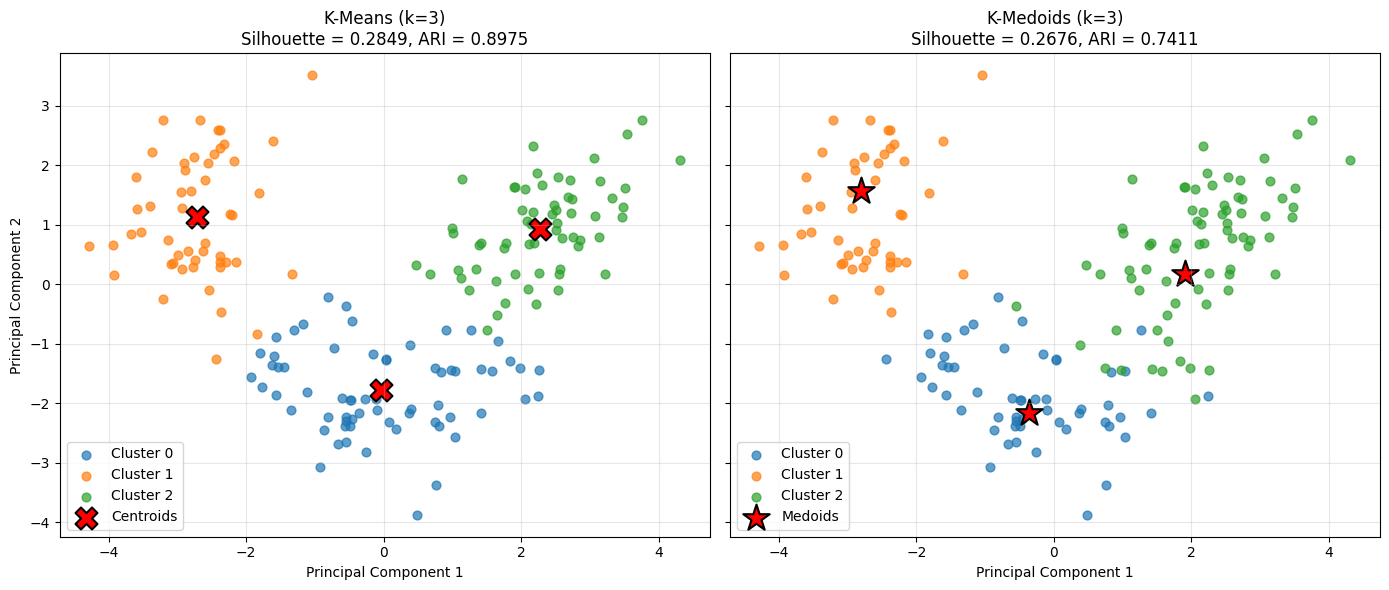

In [13]:
from sklearn.decomposition import PCA
from scipy.optimize import linear_sum_assignment

# 1) Squeeze the 13 features into 2 so we can draw the clusters
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)
km_centers_pca = pca.transform(kmeans.cluster_centers_)
medoids_pca = X_pca[medoid_indices]

# 2) Cluster numbers are arbitrary, so match the K-Medoids numbers to the K-Means numbers
#    (this only makes the same colour mean the same area in both plots)
overlap = pd.crosstab(km_labels, kmed_labels).values
rows, cols = linear_sum_assignment(-overlap)
label_map = {int(c): int(r) for r, c in zip(rows, cols)}
kmed_plot_labels = np.array([label_map[l] for l in kmed_labels])

# 3) Side-by-side plots
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharex=True, sharey=True)
colors = ["tab:blue", "tab:orange", "tab:green"]

for c in range(3):
    axes[0].scatter(X_pca[km_labels == c, 0], X_pca[km_labels == c, 1],
                    s=40, alpha=0.7, color=colors[c], label=f"Cluster {c}")
axes[0].scatter(km_centers_pca[:, 0], km_centers_pca[:, 1], marker="X", s=250,
                color="red", edgecolor="black", linewidth=1.5, label="Centroids")
axes[0].set_title(f"K-Means (k=3)\nSilhouette = {km_silhouette:.4f}, ARI = {km_ari:.4f}")
axes[0].set_xlabel("Principal Component 1")
axes[0].set_ylabel("Principal Component 2")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

for c in range(3):
    axes[1].scatter(X_pca[kmed_plot_labels == c, 0], X_pca[kmed_plot_labels == c, 1],
                    s=40, alpha=0.7, color=colors[c], label=f"Cluster {c}")
axes[1].scatter(medoids_pca[:, 0], medoids_pca[:, 1], marker="*", s=400,
                color="red", edgecolor="black", linewidth=1.5, label="Medoids")
axes[1].set_title(f"K-Medoids (k=3)\nSilhouette = {kmed_silhouette:.4f}, ARI = {kmed_ari:.4f}")
axes[1].set_xlabel("Principal Component 1")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**Which algorithm produced better-defined clusters?** K-Means did. Its Silhouette Score was a little higher (0.2849 vs. 0.2676), and its ARI was much higher (0.8975 vs. 0.7411). The silhouette gap is small, so both give clusters that are only moderately separated. The ARI gap is large: K-Means put 6 wines in the wrong group, and K-Medoids put 16 in the wrong group.

**What differences do I see in shape and position?** The top-left group is almost the same in both plots. The difference is in the other two groups. K-Medoids made the right-hand group larger (74 wines vs. 62) by taking in 12 wines that K-Means put in the bottom group. The K-Medoids group for the right side has its medoid closer to the middle of the plot than the K-Means centroid, which may explain why that group grew downward. K-Means gave more even group sizes (65, 51, 62), while K-Medoids gave 55, 49, and 74. Also, the centroids are averages and can sit anywhere, while the medoids are real wines.

**When might each be better?** K-Means works well when the data is clean, has no large outliers, and the groups are roughly round and similar in size, like the standardized Wine data here. It is also faster on large datasets. K-Medoids is better when the data has outliers or noise, because a medoid is a real data point and is not pulled around by extreme values. It is also useful when you need each center to be an actual example, or when you want to use a different distance measure. The downside is that it is slower on large data. On this dataset, K-Means is the better choice.
